<a href="https://colab.research.google.com/github/bemakerorg/AIoT_Book_II_RF/blob/main/AIoT_RF_Book_ES_21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Esercizio 21 - Realizzazione di App Keyword Spotting con YAMNet – Parte 1**

In [ ]:
# CELLA 1
# YAMNet Transfer Learning per Classificazione Speech Commands
# Riconoscimento di 4 classi: yes, no, silenzio, sconosciuto

# =============================================================================
# INSTALLAZIONE E IMPORT DELLE LIBRERIE
# =============================================================================

# Installazione delle librerie necessarie tramite pip
# !pip install esegue comandi pip direttamente dal notebook
!pip install tensorflow-hub

# Import delle librerie principali per il machine learning e data science
import tensorflow as tf          # Framework principale per deep learning
import tensorflow_hub as hub     # Per caricare modelli pre-addestrati da TensorFlow Hub
import numpy as np              # Libreria per operazioni numeriche e array
import matplotlib.pyplot as plt # Libreria per creare grafici e visualizzazioni
import os                      # Libreria per operazioni sul sistema operativo (file, directory)
import pathlib                 # Libreria per gestire path in modo più elegante
import seaborn as sns          # Libreria per visualizzazioni avanzate (basata su matplotlib)
from sklearn.metrics import confusion_matrix, classification_report  # Metriche di valutazione
import random                  # Libreria per generare numeri casuali

# Stampa delle versioni delle librerie per debugging e compatibilità
print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ TensorFlow Hub version: {hub.__version__}")
print(f"✅ NumPy version: {np.__version__}")
print(f"✅ Seaborn version: {sns.__version__}")

✅ TensorFlow version: 2.18.0
✅ TensorFlow Hub version: 0.16.1
✅ NumPy version: 2.0.2
✅ Seaborn version: 0.13.2


In [ ]:
# CELLA 2
# =============================================================================
# CONFIGURAZIONE INIZIALE
# =============================================================================

# Impostazione del seed per garantire riproducibilità dei risultati
# Il seed controlla la generazione di numeri casuali
SEED = 42
tf.random.set_seed(SEED)    # Seed per TensorFlow
np.random.seed(SEED)        # Seed per NumPy
random.seed(SEED)           # Seed per Python standard library

# Definizione delle classi target che il modello dovrà riconoscere
TARGET_CLASSES = ['yes', 'no', 'silence', 'unknown']
NUM_CLASSES = len(TARGET_CLASSES)  # Calcola automaticamente il numero di classi (4)

# Parametri di training - iperparametri del modello
BATCH_SIZE = 32        # Numero di campioni processati insieme in ogni step
EPOCHS = 20           # Numero di epoche (passate complete attraverso il dataset)
LEARNING_RATE = 0.001 # Tasso di apprendimento per l'ottimizzatore

# Parametri audio specifici per YAMNet
SAMPLE_RATE = 16000   # Frequenza di campionamento richiesta da YAMNet (16kHz)

# Stampa delle configurazioni per verifica
print(f"Classi target: {TARGET_CLASSES}")
print(f"Numero di classi: {NUM_CLASSES}")

Classi target: ['yes', 'no', 'silence', 'unknown']
Numero di classi: 4


In [ ]:
# CELLA 3
# =============================================================================
# DOWNLOAD E PREPARAZIONE DEL DATASET SPEECH COMMANDS
# =============================================================================

# Import aggiuntivi necessari per il download e gestione archivi
import urllib.request  # Per scaricare file da URL
import tarfile        # Per estrarre archivi tar.gz
import shutil         # Per operazioni su file e directory

# Definizione della funzione per download e estrazione manuale del dataset
def download_and_extract_dataset():
    """
    Scarica ed estrae manualmente il dataset Speech Commands
    Questa funzione serve come metodo di fallback se altri approcci falliscono
    """
    # URL del dataset Speech Commands versione 0.02 di Google
    url = "http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz"

    # Nome del file temporaneo che verrà scaricato
    tar_filename = "speech_commands_v0.02.tar.gz"

    # Directory di destinazione per l'estrazione
    extract_dir = "data/speech_commands_v0.02"

    # Crea la directory "data" se non esiste già
    # exist_ok=True previene errori se la directory esiste già
    os.makedirs("data", exist_ok=True)

    # Informazioni di debug per l'utente
    print("Scaricando il dataset Speech Commands...")
    print(f"URL: {url}")

    # Blocco try-except per gestire errori durante download/estrazione
    try:
        # Scarica il file dall'URL e lo salva localmente
        # urlretrieve(url, filename) scarica da url e salva come filename
        urllib.request.urlretrieve(url, tar_filename)
        print(f"Download completato: {tar_filename}")

        # Estrazione del file tar.gz scaricato
        print("Estraendo il dataset...")

        # Apre l'archivio tar.gz in modalità lettura compressa
        # 'r:gz' significa read mode con compressione gzip
        with tarfile.open(tar_filename, 'r:gz') as tar:
            # Estrae tutti i contenuti nell'archivio nella directory specificata
            tar.extractall(extract_dir)

        print(f"Estrazione completata in: {extract_dir}")

        # Rimuove il file tar.gz per liberare spazio su disco
        os.remove(tar_filename)
        print("File temporaneo rimosso.")

        # Restituisce il path come oggetto pathlib.Path per facilità d'uso
        return pathlib.Path(extract_dir)

    # Cattura qualsiasi eccezione durante il processo
    except Exception as e:
        print(f"Errore durante il download/estrazione: {e}")
        # Restituisce None per indicare fallimento
        return None

# Lista delle possibili directory dove il dataset potrebbe essere già presente
# Cerca in ordine di priorità diverse posizioni comuni
possible_dirs = [
    # Directory locale del progetto corrente
    pathlib.Path('data/speech_commands_v0.02'),
    # Directory alternativa locale
    pathlib.Path('data/speech_commands_v0_extracted'),
    # Cache locale di Keras nella directory corrente
    pathlib.Path('.keras/datasets/speech_commands_v0.02'),
    # Cache di Keras nella home directory dell'utente
    # expanduser() espande ~ nella home directory reale
    pathlib.Path('~/.keras/datasets/speech_commands_v0.02').expanduser()
]

# Inizializza la variabile che conterrà il path finale del dataset
data_dir = None

# Ciclo per cercare il dataset in tutte le directory possibili
for dir_path in possible_dirs:
    # Controlla se la directory esiste fisicamente
    if dir_path.exists():
        # Ottiene lista delle sottodirectory (rappresentano le classi audio)
        # iterdir() restituisce iteratore sui contenuti della directory
        # is_dir() filtra solo le directory, non i file
        # .name ottiene solo il nome senza il path completo
        subdirs = [d.name for d in dir_path.iterdir() if d.is_dir()]

        # Il dataset Speech Commands ha circa 35 classi, quindi verifica completezza
        if len(subdirs) > 20:  # Soglia per considerarlo completo
            print(f"Dataset trovato in: {dir_path}")
            # Imposta questa directory come directory del dataset
            data_dir = dir_path
            # Esce dal ciclo una volta trovato un dataset valido
            break

# Se il dataset non è stato trovato, prova il download con Keras
if data_dir is None:
    print("Dataset non trovato. Tentativo di download con tf.keras...")

    # Secondo tentativo: utilizza il sistema di cache integrato di Keras
    try:
        # tf.keras.utils.get_file gestisce automaticamente download e cache
        dataset_path = tf.keras.utils.get_file(
            fname='speech_commands_v0.02.tar.gz',  # Nome del file da scaricare
            origin='http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz',  # URL sorgente
            extract=True,        # Estrae automaticamente l'archivio dopo il download
            cache_dir='.',       # Directory dove salvare la cache (directory corrente)
            cache_subdir='data'  # Sottodirectory dentro cache_dir
        )

        # get_file restituisce il path del file .tar.gz, non della directory estratta
        # Quindi costruisce il path previsto della directory estratta
        dataset_dir = pathlib.Path(dataset_path).parent / 'speech_commands_v0.02'

        # Verifica se la directory estratta esiste nel path previsto
        if dataset_dir.exists():
            data_dir = dataset_dir
            print(f"Dataset scaricato e trovato in: {data_dir}")
        else:
            # Se non trova nel path previsto, cerca nella cache standard di Keras
            # Costruisce il path della cache Keras nella home directory
            keras_cache = pathlib.Path.home() / '.keras' / 'datasets'

            # Cerca tutte le directory che potrebbero contenere il dataset
            for item in keras_cache.iterdir():
                # Verifica che il nome contenga 'speech_commands' (case insensitive)
                # e che sia effettivamente una directory
                if 'speech_commands' in item.name.lower() and item.is_dir():
                    # Conta le sottodirectory per verificare che sia completo
                    subdirs = [d.name for d in item.iterdir() if d.is_dir()]
                    if len(subdirs) > 20:  # Soglia di completezza
                        data_dir = item
                        print(f"Dataset trovato nella cache Keras: {data_dir}")
                        break  # Esce dal ciclo interno

    # Gestisce eventuali errori con il metodo Keras
    except Exception as e:
        print(f"Errore con tf.keras.utils.get_file: {e}")

# Terzo tentativo: se anche Keras ha fallito, usa il download manuale
if data_dir is None:
    print("Tentativo di download manuale...")
    # Chiama la funzione di download manuale definita sopra
    data_dir = download_and_extract_dataset()

# Controllo finale: se tutti i metodi hanno fallito, genera errore critico
if data_dir is None or not data_dir.exists():
    print("ERRORE CRITICO: Non è stato possibile scaricare il dataset!")
    print("\nSoluzioni alternative:")
    print("1. Prova a scaricare manualmente da:")
    print("   http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz")
    print("2. Estrai il file nella cartella 'data/speech_commands_v0.02'")
    print("3. Verifica la connessione internet")
    # Solleva un'eccezione per interrompere l'esecuzione dello script
    raise Exception("Dataset non disponibile")

# Sezione di diagnostica e verifica della struttura del dataset
print(f"\n{'='*50}")  # Linea separatrice di 50 caratteri '='
print(f"DATASET TROVATO!")
print(f"Directory: {data_dir}")
print(f"{'='*50}")

# Analisi dettagliata del contenuto della directory del dataset
if data_dir.exists():
    # Separa sottodirectory (classi) e file nella root
    subdirs = [d.name for d in data_dir.iterdir() if d.is_dir()]
    files = [f.name for f in data_dir.iterdir() if f.is_file()]

    # Stampa statistiche generali
    print(f"Sottodirectory (classi): {len(subdirs)}")
    print(f"File nella root: {len(files)}")

    # Se ci sono sottodirectory, mostra un campione
    if len(subdirs) > 0:
        print(f"Prime 10 classi: {subdirs[:10]}")

    # Verifica la presenza delle classi più importanti per questo progetto
    target_found = []  # Lista per tracciare le classi target trovate

    # Controlla ogni classe target necessaria
    for target in ['yes', 'no', '_background_noise_']:
        # Se la classe è presente nelle sottodirectory del dataset
        if target in subdirs:
            # Aggiunge alla lista delle classi trovate
            target_found.append(target)

    print(f"Classi target trovate: {target_found}")

    # Valutazione finale della completezza per il progetto
    if len(target_found) >= 2:  # Almeno 'yes' e 'no' devono essere presenti
        print("✅ Dataset pronto per l'uso!")
    else:
        print("⚠️  Alcune classi target potrebbero mancare")
else:
    # Se per qualche ragione la directory non è accessibile
    raise Exception("Directory del dataset non accessibile")

Dataset non trovato. Tentativo di download con tf.keras...
2428923189/2428923189 ━━━━━━━━━━━━━━━━━━━━ 20s 0us/step
Errore con tf.keras.utils.get_file: [Errno 2] No such file or directory: '/root/.keras/datasets'
Tentativo di download manuale...
Scaricando il dataset Speech Commands...
URL: http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz
Download completato: speech_commands_v0.02.tar.gz
Estraendo il dataset...
Estrazione completata in: data/speech_commands_v0.02
File temporaneo rimosso.

DATASET TROVATO!
Directory: data/speech_commands_v0.02
Sottodirectory (classi): 36
File nella root: 5
Prime 10 classi: ['house', 'four', 'sheila', 'dog', 'right', 'tree', 'down', 'learn', 'forward', 'visual']
Classi target trovate: ['yes', 'no', '_background_noise_']
✅ Dataset pronto per l'uso!


In [ ]:
# CELLA 4
# =============================================================================
# FUNZIONI PER IL PREPROCESSING AUDIO
# =============================================================================

def load_wav_16k_mono(filename):
    """
    Carica un file audio WAV e lo converte a 16kHz mono usando solo TensorFlow
    Questa funzione standardizza tutti gli audio per YAMNet

    Args:
        filename: percorso del file audio da caricare

    Returns:
        audio: tensor audio normalizzato con forma (16000,)
    """
    # Legge il contenuto binario del file audio
    file_contents = tf.io.read_file(filename)

    # Decodifica il file WAV usando TensorFlow
    # desired_channels=1 forza la conversione a mono
    wav, sample_rate = tf.audio.decode_wav(
        file_contents,
        desired_channels=1  # Converte a mono (1 canale)
    )

    # Rimuove la dimensione del canale per ottenere forma (lunghezza,)
    # squeeze rimuove dimensioni di size 1
    wav = tf.squeeze(wav, axis=-1)

    # Converte il sample rate a int64 per i calcoli
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)

    # Resampling a 16kHz se necessario
    # YAMNet richiede specificamente 16kHz
    if tf.not_equal(sample_rate, 16000):
        # Calcola il fattore di resampling
        resample_factor = tf.cast(sample_rate, tf.float32) / 16000.0
        # Calcola la nuova lunghezza dopo il resampling
        new_length = tf.cast(tf.cast(tf.shape(wav)[0], tf.float32) / resample_factor, tf.int32)

        # Resampling lineare semplice usando interpolazione
        # Crea indici per il campionamento
        indices = tf.cast(tf.linspace(0.0, tf.cast(tf.shape(wav)[0] - 1, tf.float32), new_length), tf.int32)
        # Campiona i valori audio agli indici calcolati
        wav = tf.gather(wav, indices)

    # Converte a float32 per compatibilità con YAMNet
    wav = tf.cast(wav, tf.float32)

    # Standardizza la lunghezza a esattamente 1 secondo (16000 campioni)
    target_length = 16000
    current_length = tf.shape(wav)[0]

    # Se l'audio è più corto di 1 secondo, aggiunge padding con zeri
    if tf.less(current_length, target_length):
        padding = target_length - current_length
        # Aggiunge zeri alla fine dell'audio
        wav = tf.pad(wav, [[0, padding]], mode='CONSTANT')
    # Se l'audio è più lungo di 1 secondo, tronca
    else:
        wav = wav[:target_length]

    return wav

def preprocess_dataset(files, labels):
    """
    Preprocessing completo del dataset: carica audio e prepara le etichette
    Crea un tf.data.Dataset ottimizzato per il training

    Args:
        files: lista dei percorsi dei file audio
        labels: lista delle etichette numeriche corrispondenti

    Returns:
        dataset: tf.data.Dataset preprocessato con audio e label
    """
    # Crea un dataset dai percorsi dei file
    path_ds = tf.data.Dataset.from_tensor_slices(files)

    # Applica la funzione di caricamento audio a ogni percorso
    # num_parallel_calls=AUTOTUNE ottimizza automaticamente il parallelismo
    audio_ds = path_ds.map(load_wav_16k_mono, num_parallel_calls=tf.data.AUTOTUNE)

    # Crea un dataset dalle etichette
    label_ds = tf.data.Dataset.from_tensor_slices(labels)

    # Combina audio e etichette in un unico dataset
    # zip crea coppie (audio, label)
    return tf.data.Dataset.zip((audio_ds, label_ds))

In [ ]:
# CELLA 5
# =============================================================================
# PREPARAZIONE DEI DATI DI TRAINING
# =============================================================================

# Verifica preliminare che la directory del dataset esista
if not data_dir.exists():
    print(f"ERRORE: Directory {data_dir} non esiste!")
    print("Prova a ri-eseguire la sezione di download del dataset.")
else:
    # Elenca tutti gli elementi nella directory del dataset
    all_items = list(data_dir.iterdir())
    # Separa directory (classi) dai file
    directories = [item for item in all_items if item.is_dir()]
    files = [item for item in all_items if item.is_file()]

    print(f"Directory trovate: {len(directories)}")
    print(f"File trovati: {len(files)}")

    # Controllo di sanità: verifica che ci siano abbastanza directory
    # Il dataset dovrebbe avere circa 35 classi
    if len(directories) < 10:
        print("ATTENZIONE: Trovate poche directory. Possibile problema nell'estrazione.")
        print("Directory disponibili:")
        for d in directories:
            print(f"  - {d.name}")

        # Cerca una sottodirectory che potrebbe contenere il dataset estratto
        for d in directories:
            # Controlla se questa directory contiene molte sottodirectory
            sub_dirs = [item for item in d.iterdir() if item.is_dir()]
            if len(sub_dirs) > 20:  # Soglia per dataset completo
                print(f"Dataset probabilmente in: {d}")
                data_dir = d  # Aggiorna il path del dataset
                break

    # Ottiene i nomi di tutte le classi (directory) disponibili
    commands = [d.name for d in data_dir.iterdir() if d.is_dir()]
    # Rimuove eventuali file README.md dalla lista delle classi
    commands = [cmd for cmd in commands if cmd != 'README.md']

    print(f"Directory dataset finale: {data_dir}")
    print(f"Classi disponibili nel dataset: {len(commands)}")
    print(f"Prime 10 classi: {commands[:10] if len(commands) >= 10 else commands}")

# Inizializzazione delle liste per raccogliere tutti i file e le etichette
all_files = []   # Lista di tutti i percorsi dei file audio
all_labels = []  # Lista di tutte le etichette corrispondenti

# Raccolta dei file per le classi 'yes' e 'no'
# Queste sono le classi principali del progetto
for target_class in ['yes', 'no']:
    # Verifica che la classe esista nel dataset
    if target_class in commands:
        # Costruisce il path della directory della classe
        class_dir = data_dir / target_class
        if class_dir.exists():
            # Trova tutti i file .wav nella directory della classe
            files = list(class_dir.glob('*.wav'))
            # Converte i Path objects in stringhe per compatibilità
            files = [str(f) for f in files]
            # Aggiunge i file alla lista generale
            all_files.extend(files)
            # Aggiunge le etichette corrispondenti (ripetute per ogni file)
            all_labels.extend([target_class] * len(files))
            print(f"Classe '{target_class}': {len(files)} file")
        else:
            print(f"ATTENZIONE: Directory '{class_dir}' non esiste.")
    else:
        print(f"ATTENZIONE: La classe '{target_class}' non è stata trovata nel dataset.")

# Raccolta dei file per la classe 'silence' (rumore di fondo)
silence_dir = data_dir / '_background_noise_'
if silence_dir.exists() and '_background_noise_' in commands:
    # Trova tutti i file audio nella directory del rumore di fondo
    silence_files = list(silence_dir.glob('*.wav'))
    silence_files = [str(f) for f in silence_files]
    # Limita il numero di file di silenzio per bilanciare il dataset
    # Troppi file di background noise potrebbero sbilanciare il training
    silence_files = silence_files[:1000] if len(silence_files) > 1000 else silence_files
    all_files.extend(silence_files)
    # Etichetta questi file come 'silence'
    all_labels.extend(['silence'] * len(silence_files))
    print(f"Classe 'silence': {len(silence_files)} file")
else:
    print(f"ATTENZIONE: La directory '_background_noise_' non è stata trovata nel dataset.")
    print(f"Directory cercata: {silence_dir}")

# Raccolta dei file per la classe 'unknown' (tutte le altre parole)
# Escludi le classi che abbiamo già processato
exclude_classes = ['yes', 'no', '_background_noise_', 'silence']
unknown_classes = [cmd for cmd in commands if cmd not in exclude_classes]
unknown_files = []  # Lista temporanea per i file unknown
max_files_per_class = 200  # Limita i file per classe per bilanciare
max_unknown_classes = 10   # Limita il numero di classi unknown

print(f"Classi disponibili per 'unknown': {len(unknown_classes)}")
if len(unknown_classes) > 0:
    print(f"Prime classi 'unknown': {unknown_classes[:5]}")

# Itera attraverso le classi sconosciute (limitate)
for i, unknown_class in enumerate(unknown_classes[:max_unknown_classes]):
    class_dir = data_dir / unknown_class
    if class_dir.exists():
        # Trova i file audio della classe
        files = list(class_dir.glob('*.wav'))
        files = [str(f) for f in files]
        # Limita il numero di file per evitare sbilanciamento
        files_to_add = files[:max_files_per_class]
        unknown_files.extend(files_to_add)
        print(f"  Classe '{unknown_class}': {len(files_to_add)} file aggiunti")

# Aggiunge tutti i file unknown al dataset principale
all_files.extend(unknown_files)
all_labels.extend(['unknown'] * len(unknown_files))
print(f"Classe 'unknown': {len(unknown_files)} file totali")

print(f"Totale file nel dataset: {len(all_files)}")

# Conversione delle etichette testuali in indici numerici
# Crea mapping bidirezionale tra etichette e indici
label_to_index = {label: idx for idx, label in enumerate(TARGET_CLASSES)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

# Filtra i file con etichette valide e converte le etichette in numeri
valid_files = []     # File con etichette valide
valid_labels = []    # Etichette numeriche corrispondenti
for file_path, label in zip(all_files, all_labels):
    # Verifica che l'etichetta sia nelle classi target
    if label in label_to_index:
        valid_files.append(file_path)
        valid_labels.append(label_to_index[label])  # Converte a indice numerico
    else:
        print(f"ATTENZIONE: Etichetta '{label}' non valida per il file '{file_path}'. Ignorata.")

# Aggiorna le liste con solo i dati validi
all_files = valid_files
numeric_labels = valid_labels

print(f"Mappatura classi: {label_to_index}")
print(f"Totale file validi nel dataset: {len(all_files)}")

# Analisi della distribuzione delle classi per verificare il bilanciamento
if len(all_files) > 0:
    from collections import Counter
    # Conta occorrenze di ogni etichetta
    label_counts = Counter(all_labels)
    print("\nDistribuzione delle classi:")
    for label, count in label_counts.items():
        print(f"  {label}: {count} file")
else:
    print("\nERRORE: Nessun file è stato trovato nel dataset!")
    print("Verifica che il dataset sia stato scaricato ed estratto correttamente.")

Directory trovate: 36
File trovati: 5
Directory dataset finale: data/speech_commands_v0.02
Classi disponibili nel dataset: 36
Prime 10 classi: ['house', 'four', 'sheila', 'dog', 'right', 'tree', 'down', 'learn', 'forward', 'visual']
Classe 'yes': 4044 file
Classe 'no': 3941 file
Classe 'silence': 6 file
Classi disponibili per 'unknown': 33
Prime classi 'unknown': ['house', 'four', 'sheila', 'dog', 'right']
  Classe 'house': 200 file aggiunti
  Classe 'four': 200 file aggiunti
  Classe 'sheila': 200 file aggiunti
  Classe 'dog': 200 file aggiunti
  Classe 'right': 200 file aggiunti
  Classe 'tree': 200 file aggiunti
  Classe 'down': 200 file aggiunti
  Classe 'learn': 200 file aggiunti
  Classe 'forward': 200 file aggiunti
  Classe 'visual': 200 file aggiunti
Classe 'unknown': 2000 file totali
Totale file nel dataset: 9991
Mappatura classi: {'yes': 0, 'no': 1, 'silence': 2, 'unknown': 3}
Totale file validi nel dataset: 9991

Distribuzione delle classi:
  yes: 4044 file
  no: 3941 file
 

In [ ]:
# CELLA 6
# =============================================================================
# DIVISIONE TRAIN/VALIDATION/TEST
# =============================================================================

# Creazione di indici randomizzati per dividere il dataset in modo casuale
total_samples = len(all_files)  # Numero totale di campioni
indices = list(range(total_samples))  # Lista di indici [0, 1, 2, ..., total_samples-1]
random.shuffle(indices)  # Mescola gli indici in modo casuale

# Definizione delle proporzioni per la divisione del dataset
# Divisione standard: 70% training, 15% validation, 15% test
train_size = int(0.7 * total_samples)   # 70% per training
val_size = int(0.15 * total_samples)    # 15% per validation

# Divisione degli indici in tre set disgiunti
train_indices = indices[:train_size]                                   # Primi 70%
val_indices = indices[train_size:train_size + val_size]                # Successivi 15%
test_indices = indices[train_size + val_size:]                         # Rimanenti 15%

# Creazione dei dataset separati usando gli indici
# Training set
train_files = [all_files[i] for i in train_indices]       # File per training
train_labels = [numeric_labels[i] for i in train_indices] # Etichette per training

# Validation set
val_files = [all_files[i] for i in val_indices]          # File per validation
val_labels = [numeric_labels[i] for i in val_indices]    # Etichette per validation

# Test set
test_files = [all_files[i] for i in test_indices]        # File per test
test_labels = [numeric_labels[i] for i in test_indices]  # Etichette per test

# Stampa delle dimensioni dei dataset per verifica
print(f"Dataset di training: {len(train_files)} campioni")
print(f"Dataset di validazione: {len(val_files)} campioni")
print(f"Dataset di test: {len(test_files)} campioni")

Dataset di training: 6993 campioni
Dataset di validazione: 1498 campioni
Dataset di test: 1500 campioni


In [ ]:
# CELLA 7
# =============================================================================
# CREAZIONE DEI DATASET TENSORFLOW
# =============================================================================

# Creazione dei dataset TensorFlow usando la funzione di preprocessing
# Ogni dataset applica automaticamente il caricamento e preprocessing audio
train_ds = preprocess_dataset(train_files, train_labels)  # Dataset di training
val_ds = preprocess_dataset(val_files, val_labels)        # Dataset di validation
test_ds = preprocess_dataset(test_files, test_labels)     # Dataset di test

# Applicazione di ottimizzazioni per migliorare le performance
# batch(BATCH_SIZE): raggruppa i campioni in batch di dimensione specificata
# cache(): mantiene il dataset in memoria dopo la prima epoca per velocizzare
# prefetch(AUTOTUNE): prepara il batch successivo mentre il modello elabora quello corrente
train_ds = train_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

print("Dataset TensorFlow creati e ottimizzati")

Dataset TensorFlow creati e ottimizzati


In [ ]:
# CELLA 8
# =============================================================================
# CARICAMENTO DEL MODELLO YAMNET PRE-ADDESTRATO
# =============================================================================

# Definisce l'URL del modello YAMNet pre-addestrato su TensorFlow Hub
yamnet_model_handle = "https://tfhub.dev/google/yamnet/1"
# Carica il modello YAMNet da TensorFlow Hub utilizzando l'URL specificato
yamnet_model = hub.load(yamnet_model_handle)

# Stampa un messaggio di conferma che il modello è stato caricato correttamente
print("Modello YAMNet caricato da TensorFlow Hub")

# =============================================================================
# FUNZIONE PER ESTRARRE FEATURES CON YAMNET
# =============================================================================

def extract_yamnet_features(audio_batch):
    """
    Estrae le features da un batch di audio usando YAMNet

    Args:
        audio_batch: batch di dati audio con forma (batch_size, audio_length)

    Returns:
        features: features estratte da YAMNet (embeddings)
    """
    # Controlla se il tensore audio è 1D (singolo audio senza dimensione batch)
    if len(tf.shape(audio_batch)) == 1:
        # Aggiunge una dimensione batch al tensore 1D per renderlo 2D
        audio_batch = tf.expand_dims(audio_batch, 0)
    # Controlla se il tensore è 3D (con dimensione canale extra)
    elif len(tf.shape(audio_batch)) == 3:
        # Rimuove la dimensione del canale (ultima dimensione) per renderlo 2D
        audio_batch = tf.squeeze(audio_batch, axis=-1)

    # Passa l'audio attraverso YAMNet e ottiene scores, embeddings e spettrogramma
    # Ignora scores e spettrogramma (usando _), tiene solo gli embeddings
    _, embeddings, _ = yamnet_model(audio_batch)

    # Calcola la media degli embeddings lungo l'asse temporale (axis=1)
    # Questo riduce ogni sequenza di frame audio a un singolo vettore feature
    features = tf.reduce_mean(embeddings, axis=1)

    # Restituisce le features estratte
    return features

def create_transfer_learning_model():
    """
    Crea il modello di transfer learning con YAMNet come feature extractor

    Returns:
        model: modello Keras compilato
    """
    # Definisce il layer di input che accetta audio di 16000 campioni (1 secondo a 16kHz)
    audio_input = tf.keras.layers.Input(shape=(16000,), dtype=tf.float32, name='audio_input')

    # Crea un layer Lambda che applica la funzione extract_yamnet_features
    # output_shape=(1024,) specifica che YAMNet produce embeddings di 1024 dimensioni
    yamnet_features = tf.keras.layers.Lambda(
        extract_yamnet_features,
        output_shape=(1024,),  # YAMNet produce embeddings di 1024 dimensioni
        name='yamnet_features'
    )(audio_input)

    # Primo layer denso con 256 neuroni e attivazione ReLU per la classificazione
    x = tf.keras.layers.Dense(256, activation='relu', name='dense_1')(yamnet_features)
    # Dropout del 30% per prevenire l'overfitting
    x = tf.keras.layers.Dropout(0.3, name='dropout_1')(x)

    # Secondo layer denso con 128 neuroni e attivazione ReLU
    x = tf.keras.layers.Dense(128, activation='relu', name='dense_2')(x)
    # Dropout del 30% per prevenire l'overfitting
    x = tf.keras.layers.Dropout(0.3, name='dropout_2')(x)

    # Terzo layer denso con 64 neuroni e attivazione ReLU
    x = tf.keras.layers.Dense(64, activation='relu', name='dense_3')(x)
    # Dropout del 20% (minore rispetto ai layer precedenti)
    x = tf.keras.layers.Dropout(0.2, name='dropout_3')(x)

    # Layer di output finale con NUM_CLASSES neuroni e attivazione softmax per classificazione multi-classe
    output = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', name='classification')(x)

    # Crea il modello Keras specificando input e output
    model = tf.keras.Model(inputs=audio_input, outputs=output, name='yamnet_transfer_learning')

    # Restituisce il modello creato
    return model

# =============================================================================
# COSTRUZIONE DEL MODELLO DI TRANSFER LEARNING
# =============================================================================

# Importa TensorFlow (necessario per definire la classe personalizzata)
import tensorflow as tf

class YAMNetFeatureExtractor(tf.keras.layers.Layer):
    """
    Layer personalizzato per l'estrazione di features con YAMNet
    """
    def __init__(self, yamnet_model, **kwargs):
        # Chiama il costruttore della classe parent (Layer)
        super(YAMNetFeatureExtractor, self).__init__(**kwargs)
        # Salva il modello YAMNet come attributo della classe
        self.yamnet_model = yamnet_model

    def call(self, inputs):
        # YAMNet si aspetta tensori 1D, ma Keras passa batch 2D
        # Usa tf.map_fn per processare ogni audio nel batch

        def process_single_audio(audio):
            """Processa un singolo audio e restituisce features medie"""
            # Passa l'audio singolo attraverso YAMNet, ignora scores e spettrogramma
            _, embeddings, _ = self.yamnet_model(audio)
            # Calcola la media degli embeddings lungo l'asse temporale
            return tf.reduce_mean(embeddings, axis=0)

        # Usa tf.map_fn per applicare process_single_audio a ogni elemento del batch
        # fn_output_signature specifica la forma dell'output (1024 dimensioni)
        # parallel_iterations=1 evita problemi di concorrenza
        features = tf.map_fn(
            process_single_audio,
            inputs,
            fn_output_signature=tf.TensorSpec(shape=(1024,), dtype=tf.float32),
            parallel_iterations=1
        )

        # Restituisce le features estratte per tutto il batch
        return features

    def get_config(self):
        # Ottiene la configurazione del layer parent per la serializzazione
        config = super(YAMNetFeatureExtractor, self).get_config()
        # Restituisce la configurazione (necessario per salvare/caricare il modello)
        return config

def extract_yamnet_features(audio_batch):
    """
    Estrae features YAMNet da un batch di audio

    Args:
        audio_batch: Tensore di forma (batch_size, 16000)

    Returns:
        features: Tensore di forma (batch_size, 1024)
    """
    def process_single_audio(audio):
        """Processa un singolo audio e restituisce features medie"""
        # Passa l'audio attraverso YAMNet, ottiene embeddings
        _, embeddings, _ = yamnet_model(audio)
        # Calcola la media temporale degli embeddings
        return tf.reduce_mean(embeddings, axis=0)

    # Usa tf.map_fn per processare ogni audio nel batch separatamente
    # Questo è necessario perché YAMNet elabora un audio alla volta
    features = tf.map_fn(
        process_single_audio,
        audio_batch,
        fn_output_signature=tf.TensorSpec(shape=(1024,), dtype=tf.float32),
        parallel_iterations=1
    )

    # Restituisce le features estratte
    return features

def create_transfer_learning_model_v2():
    """
    Versione migliorata del modello di transfer learning

    Returns:
        model: modello Keras compilato
    """
    # Definisce il layer di input per audio di 1 secondo (16000 campioni a 16kHz)
    audio_input = tf.keras.layers.Input(shape=(16000,), dtype=tf.float32, name='audio_input')

    # Usa il layer personalizzato YAMNetFeatureExtractor per estrarre features
    yamnet_features = YAMNetFeatureExtractor(yamnet_model, name='yamnet_extractor')(audio_input)

    # Primo blocco: Dense + BatchNormalization + Dropout
    # Layer denso con 256 neuroni e attivazione ReLU
    x = tf.keras.layers.Dense(256, activation='relu', name='dense_1')(yamnet_features)
    # Normalizzazione batch per stabilizzare l'addestramento
    x = tf.keras.layers.BatchNormalization(name='bn_1')(x)
    # Dropout del 30% per regolarizzazione
    x = tf.keras.layers.Dropout(0.3, name='dropout_1')(x)

    # Secondo blocco: Dense + BatchNormalization + Dropout
    # Layer denso con 128 neuroni e attivazione ReLU
    x = tf.keras.layers.Dense(128, activation='relu', name='dense_2')(x)
    # Normalizzazione batch
    x = tf.keras.layers.BatchNormalization(name='bn_2')(x)
    # Dropout del 30%
    x = tf.keras.layers.Dropout(0.3, name='dropout_2')(x)

    # Terzo blocco: Dense + BatchNormalization + Dropout
    # Layer denso con 64 neuroni e attivazione ReLU
    x = tf.keras.layers.Dense(64, activation='relu', name='dense_3')(x)
    # Normalizzazione batch
    x = tf.keras.layers.BatchNormalization(name='bn_3')(x)
    # Dropout del 20% (ridotto rispetto ai layer precedenti)
    x = tf.keras.layers.Dropout(0.2, name='dropout_3')(x)

    # Layer di output con 4 classi (hardcoded invece di NUM_CLASSES)
    # Attivazione softmax per classificazione multi-classe
    output = tf.keras.layers.Dense(4, activation='softmax', name='classification')(x)  # Ho usato 4 invece di NUM_CLASSES

    # Crea il modello Keras completo
    model = tf.keras.Model(inputs=audio_input, outputs=output, name='yamnet_transfer_learning_v2')

    # Restituisce il modello
    return model

# Crea un'istanza del modello utilizzando la versione migliorata
model = create_transfer_learning_model_v2()

# Compila il modello specificando:
# - Ottimizzatore Adam con learning rate definito in LEARNING_RATE
# - Funzione di loss per classificazione multi-classe con etichette integer
# - Metrica di accuracy per monitorare le performance
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Stampa un riassunto dell'architettura del modello
model.summary()

# Importa il modulo os per operazioni sul file system
import os

# Percorso temporaneo per salvare il modello e calcolare le dimensioni
temp_model_path = 'temp_model.h5'
# Salva il modello in formato HDF5
model.save(temp_model_path)
# Calcola la dimensione del file in MB
model_size_MB = os.path.getsize(temp_model_path) / (1024 * 1024)
# Stampa la dimensione del modello
print(f"\nDimensione approssimativa del modello salvato: {model_size_MB:.2f} MB")
# Rimuove il file temporaneo
os.remove(temp_model_path)

Modello YAMNet caricato da TensorFlow Hub


Model: "yamnet_transfer_learning_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ audio_input (InputLayer)        │ (None, 16000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ yamnet_extractor                │ (None, 1024)           │             0 │
│ (YAMNetFeatureExtractor)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,604 (1.17 MB)

 Trainable params: 304,708 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)


Dimensione approssimativa del modello salvato: 1.21 MB


In [ ]:
# CELLA 9
# =============================================================================
# CALLBACK PER IL TRAINING
# =============================================================================

# Callback per salvare automaticamente il miglior modello durante l'addestramento
# Monitora la validation accuracy e salva solo quando migliora
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_yamnet_model.h5',    # Percorso dove salvare il modello
    monitor='val_accuracy',              # Metrica da monitorare
    save_best_only=True,                # Salva solo se migliora
    save_weights_only=False,             # Salva il modello completo, non solo i pesi
    verbose=1                           # Stampa messaggi quando salva
)

# Callback per ridurre il learning rate quando la validation loss smette di migliorare
reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',     # Monitora la validation loss
    factor=0.2,            # Fattore di riduzione (nuovo_lr = vecchio_lr * 0.2)
    patience=3,            # Numero di epoche da aspettare prima di ridurre
    min_lr=1e-7,          # Learning rate minimo
    verbose=1             # Stampa messaggi quando riduce il learning rate
)

# Callback per interrompere l'addestramento se non ci sono miglioramenti
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',      # Monitora la validation accuracy
    patience=5,                  # Numero di epoche senza miglioramenti prima di fermarsi
    verbose=1,                   # Stampa messaggi quando si ferma
    restore_best_weights=True    # Ripristina i pesi migliori alla fine
)

Inizio del training...
Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.4842 - loss: 1.3591
Epoch 1: val_accuracy improved from -inf to 0.69426, saving model to best_yamnet_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 180s 741ms/step - accuracy: 0.4846 - loss: 1.3581 - val_accuracy: 0.6943 - val_loss: 0.8608 - learning_rate: 0.0010
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.6777 - loss: 0.8433
Epoch 2: val_accuracy improved from 0.69426 to 0.70561, saving model to best_yamnet_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 197s 717ms/step - accuracy: 0.6777 - loss: 0.8432 - val_accuracy: 0.7056 - val_loss: 0.7488 - learning_rate: 0.0010
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.7027 - loss: 0.7527
Epoch 3: val_accuracy improved from 0.70561 to 0.71495, saving model to best_yamnet_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 200s 715ms/step - accuracy: 0.7027 - loss: 0.7526 - val_accuracy: 0.7150 - val_loss: 0.6965 - learning_rate: 0.0010
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.7228 - loss: 0.6814
Epoch 4: val_accuracy improved from 0.71495 to 0.72029, saving model to best_yamnet_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 158s 723ms/step - accuracy: 0.7228 - loss: 0.6813 - val_accuracy: 0.7203 - val_loss: 0.6721 - learning_rate: 0.0010
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.7332 - loss: 0.6494
Epoch 5: val_accuracy improved from 0.72029 to 0.72563, saving model to best_yamnet_model.h5


...

219/219 ━━━━━━━━━━━━━━━━━━━━ 202s 722ms/step - accuracy: 0.7588 - loss: 0.5689 - val_accuracy: 0.7350 - val_loss: 0.6482 - learning_rate: 0.0010
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.7693 - loss: 0.5612
Epoch 11: val_accuracy did not improve from 0.73498
219/219 ━━━━━━━━━━━━━━━━━━━━ 161s 736ms/step - accuracy: 0.7694 - loss: 0.5611 - val_accuracy: 0.7316 - val_loss: 0.6417 - learning_rate: 0.0010
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - accuracy: 0.7778 - loss: 0.5388
Epoch 12: val_accuracy improved from 0.73498 to 0.73765, saving model to best_yamnet_model.h5



Epoch 12: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
219/219 ━━━━━━━━━━━━━━━━━━━━ 210s 773ms/step - accuracy: 0.7778 - loss: 0.5388 - val_accuracy: 0.7377 - val_loss: 0.6548 - learning_rate: 0.0010
Epoch 13/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.7899 - loss: 0.5090
Epoch 13: val_accuracy improved from 0.73765 to 0.74566, saving model to best_yamnet_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 159s 728ms/step - accuracy: 0.7899 - loss: 0.5088 - val_accuracy: 0.7457 - val_loss: 0.6229 - learning_rate: 2.0000e-04
Epoch 14/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.7975 - loss: 0.4969
Epoch 14: val_accuracy improved from 0.74566 to 0.75234, saving model to best_yamnet_model.h5


219/219 ━━━━━━━━━━━━━━━━━━━━ 159s 725ms/step - accuracy: 0.7976 - loss: 0.4967 - val_accuracy: 0.7523 - val_loss: 0.6183 - learning_rate: 2.0000e-04
Epoch 15/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.8162 - loss: 0.4627
Epoch 15: val_accuracy did not improve from 0.75234
219/219 ━━━━━━━━━━━━━━━━━━━━ 159s 725ms/step - accuracy: 0.8162 - loss: 0.4626 - val_accuracy: 0.7517 - val_loss: 0.6243 - learning_rate: 2.0000e-04
Epoch 16/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.8181 - loss: 0.4520
Epoch 16: val_accuracy did not improve from 0.75234
219/219 ━━━━━━━━━━━━━━━━━━━━ 222s 815ms/step - accuracy: 0.8181 - loss: 0.4519 - val_accuracy: 0.7497 - val_loss: 0.6186 - learning_rate: 2.0000e-04
Epoch 17/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 0.8199 - loss: 0.4495
Epoch 17: val_accuracy did not improve from 0.75234

Epoch 17: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
219/219 ━━━━━━━━━━━━━━━━━━━━ 181s 720ms/step - accu

219/219 ━━━━━━━━━━━━━━━━━━━━ 180s 821ms/step - accuracy: 0.8349 - loss: 0.4158 - val_accuracy: 0.7583 - val_loss: 0.6226 - learning_rate: 4.0000e-05
Epoch 20/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.8367 - loss: 0.4219
Epoch 20: val_accuracy did not improve from 0.75834

Epoch 20: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.
219/219 ━━━━━━━━━━━━━━━━━━━━ 161s 737ms/step - accuracy: 0.8367 - loss: 0.4218 - val_accuracy: 0.7570 - val_loss: 0.6223 - learning_rate: 4.0000e-05
Restoring model weights from the end of the best epoch: 19.
Training completato!


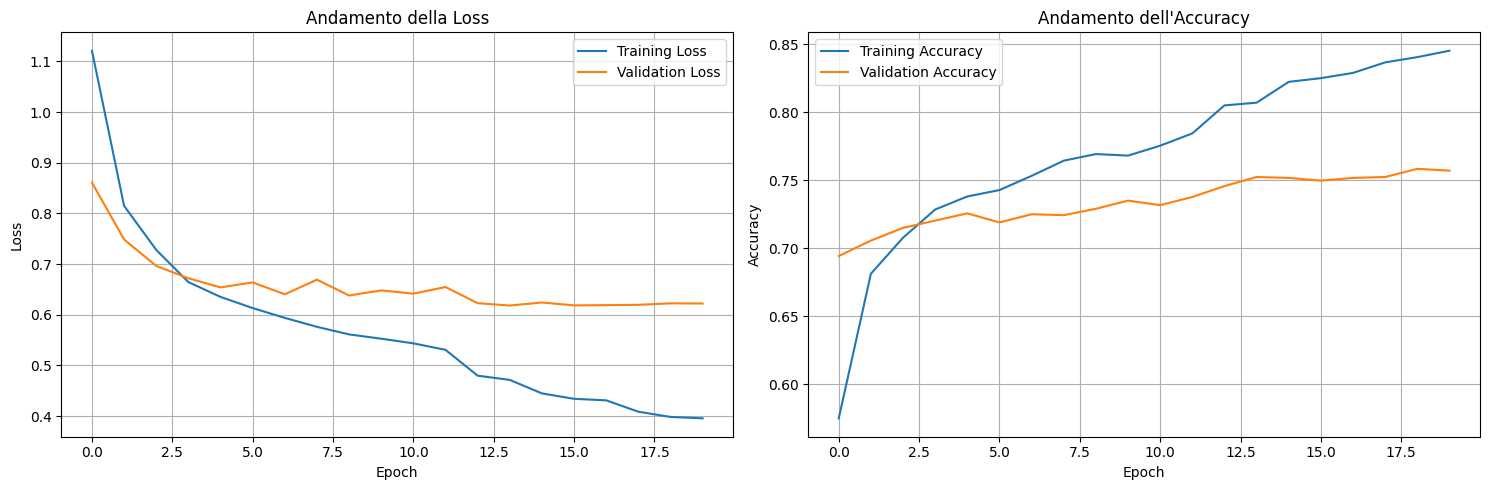

In [ ]:
# CELLA 10
# =============================================================================
# TRAINING DEL MODELLO
# =============================================================================

# Stampa messaggio di inizio training
print("Inizio del training...")
print("=" * 50)

# Avvia l'addestramento del modello
history = model.fit(
    train_ds,                    # Dataset di training
    validation_data=val_ds,      # Dataset di validazione
    epochs=EPOCHS,               # Numero di epoche (definito precedentemente)
    callbacks=[checkpoint_callback, reduce_lr_callback, early_stopping_callback],  # Lista dei callback
    verbose=1                    # Mostra progress bar dettagliato
)

# Stampa messaggio di completamento
print("Training completato!")

# =============================================================================
# VISUALIZZAZIONE DEI RISULTATI DI TRAINING
# =============================================================================

def plot_training_history(history):
    """
    Visualizza l'andamento di loss e accuracy durante il training

    Args:
        history: storia del training restituita da model.fit()
    """
    # Crea una figura con due subplot affiancati
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Primo subplot: andamento della loss
    # Plotta la loss di training
    ax1.plot(history.history['loss'], label='Training Loss')
    # Plotta la loss di validazione
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    # Imposta il titolo del grafico
    ax1.set_title('Andamento della Loss')
    # Etichetta asse x
    ax1.set_xlabel('Epoch')
    # Etichetta asse y
    ax1.set_ylabel('Loss')
    # Mostra la legenda
    ax1.legend()
    # Aggiunge una griglia per facilitare la lettura
    ax1.grid(True)

    # Secondo subplot: andamento dell'accuracy
    # Plotta l'accuracy di training
    ax2.plot(history.history['accuracy'], label='Training Accuracy')
    # Plotta l'accuracy di validazione
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    # Imposta il titolo del grafico
    ax2.set_title('Andamento dell\'Accuracy')
    # Etichetta asse x
    ax2.set_xlabel('Epoch')
    # Etichetta asse y
    ax2.set_ylabel('Accuracy')
    # Mostra la legenda
    ax2.legend()
    # Aggiunge una griglia
    ax2.grid(True)

    # Ottimizza il layout per evitare sovrapposizioni
    plt.tight_layout()
    # Mostra i grafici
    plt.show()

# Chiama la funzione per visualizzare l'andamento del training
plot_training_history(history)

Valutazione del modello sul test set...
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 469ms/step - accuracy: 0.7843 - loss: 0.5496
Test Loss: 0.5532
Test Accuracy: 0.7813
Generazione delle predizioni...
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 438ms/step


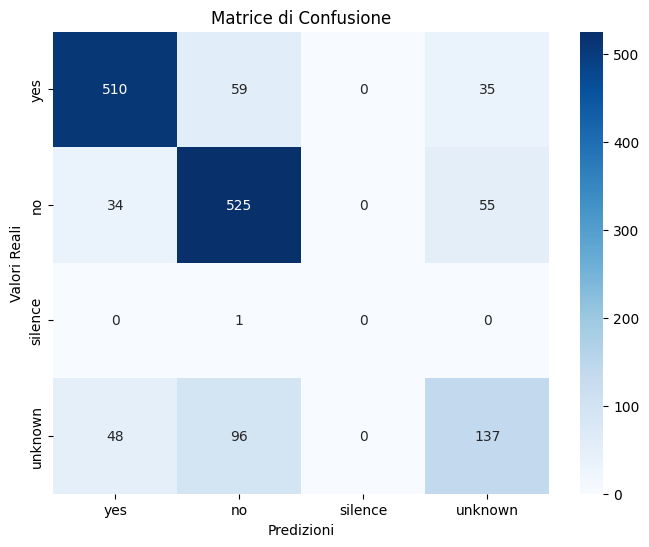


Report di Classificazione:
              precision    recall  f1-score   support

         yes       0.86      0.84      0.85       604
          no       0.77      0.86      0.81       614
     silence       0.00      0.00      0.00         1
     unknown       0.60      0.49      0.54       281

    accuracy                           0.78      1500
   macro avg       0.56      0.55      0.55      1500
weighted avg       0.78      0.78      0.78      1500



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# CELLA 11
# =============================================================================
# VALUTAZIONE DEL MODELLO SUL TEST SET
# =============================================================================

# Stampa messaggio di inizio valutazione
print("Valutazione del modello sul test set...")
print("=" * 40)

# Valuta il modello sul dataset di test e ottiene loss e accuracy
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

# Stampa i risultati della valutazione formattati a 4 decimali
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# =============================================================================
# PREDIZIONI E MATRICE DI CONFUSIONE
# =============================================================================

# Stampa messaggio di inizio generazione predizioni
print("Generazione delle predizioni...")
# Genera predizioni per tutto il test set
predictions = model.predict(test_ds)
# Converte le probabilità in classi predette (indice della classe con probabilità massima)
predicted_classes = np.argmax(predictions, axis=1)

# Crea la matrice di confusione comparando etichette vere e predizioni
cm = confusion_matrix(test_labels, predicted_classes)

# Crea una figura per visualizzare la matrice di confusione
plt.figure(figsize=(8, 6))
# Crea una heatmap della matrice di confusione
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TARGET_CLASSES,     # Etichette asse x (classi predette)
            yticklabels=TARGET_CLASSES)     # Etichette asse y (classi vere)
# Imposta il titolo del grafico
plt.title('Matrice di Confusione')
# Etichetta asse x
plt.xlabel('Predizioni')
# Etichetta asse y
plt.ylabel('Valori Reali')
# Mostra il grafico
plt.show()

# Stampa intestazione per il report di classificazione
print("\nReport di Classificazione:")
print("=" * 50)
# Genera e stampa un report dettagliato con precision, recall, f1-score per ogni classe
print(classification_report(test_labels, predicted_classes,
                          target_names=TARGET_CLASSES))

In [ ]:
# CELLA 12
# =============================================================================
# FUNZIONE PER TESTARE IL MODELLO SU NUOVI AUDIO
# =============================================================================

def predict_audio_class(audio_path, model=model):
    """
    Predice la classe di un file audio

    Args:
        audio_path: percorso del file audio
        model: modello addestrato

    Returns:
        predicted_class: classe predetta
        confidence: confidenza della predizione
    """
    # Carica il file audio usando la funzione definita precedentemente
    audio = load_wav_16k_mono(audio_path)

    # Aggiunge la dimensione batch (da 1D a 2D) per compatibilità con il modello
    audio_batch = tf.expand_dims(audio, 0)

    # Genera predizioni usando il modello (verbose=0 per non stampare progress)
    predictions = model.predict(audio_batch, verbose=0)
    # Trova l'indice della classe con probabilità massima
    predicted_idx = np.argmax(predictions[0])
    # Ottiene il valore di confidenza (probabilità) per la classe predetta
    confidence = predictions[0][predicted_idx]

    # Converte l'indice numerico nella corrispondente etichetta testuale
    predicted_class = index_to_label[predicted_idx]

    # Restituisce la classe predetta e la confidenza
    return predicted_class, confidence

In [ ]:
# CELLA 13
# =============================================================================
# SALVATAGGIO DEL MODELLO FINALE
# =============================================================================

# Salva il modello completo in formato HDF5
model.save('yamnet_speech_commands_final.h5')
# Stampa messaggio di conferma del salvataggio
print("Modello salvato come 'yamnet_speech_commands_final.h5'")

# Importa json per salvare i metadati in formato JSON
import json

# Crea un dizionario con tutti i metadati importanti del modello
model_metadata = {
    'target_classes': TARGET_CLASSES,           # Lista delle classi target
    'label_to_index': label_to_index,          # Mappatura da etichetta a indice
    'index_to_label': index_to_label,          # Mappatura da indice a etichetta
    'num_classes': NUM_CLASSES,                # Numero totale di classi
    'sample_rate': SAMPLE_RATE,                # Frequenza di campionamento audio
    'test_accuracy': float(test_accuracy),     # Accuracy sul test set
    'test_loss': float(test_loss)              # Loss sul test set
}

# Salva i metadati in un file JSON con indentazione per leggibilità
with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

# Stampa messaggio di conferma del salvataggio dei metadati
print("Metadati del modello salvati in 'model_metadata.json'")

Modello salvato come 'yamnet_speech_commands_final.h5'
Metadati del modello salvati in 'model_metadata.json'


In [ ]:
# CELLA 14
# =============================================================================
# ESEMPIO DI UTILIZZO DEL MODELLO
# =============================================================================

# Stampa intestazione della sezione di esempio
print("\n" + "=" * 60)
print("ESEMPIO DI UTILIZZO DEL MODELLO ADDESTRATO")
print("=" * 60)

# Seleziona 5 indici casuali dal test set per testare il modello
sample_indices = random.sample(range(len(test_files)), 5)

# Stampa intestazione per i test
print("Testando il modello su alcuni campioni casuali:")
print("-" * 50)

# Itera attraverso gli indici selezionati casualmente
for i, idx in enumerate(sample_indices):
    # Ottiene il percorso del file audio
    file_path = test_files[idx]
    # Ottiene la classe vera dal test set usando l'indice
    true_class = index_to_label[test_labels[idx]]

    # Usa la funzione per predire la classe dell'audio
    predicted_class, confidence = predict_audio_class(file_path)

    # Stampa i risultati per questo campione
    print(f"Campione {i+1}:")
    # Nome del file (solo basename, senza percorso completo)
    print(f"  File: {os.path.basename(file_path)}")
    # Classe reale
    print(f"  Classe reale: {true_class}")
    # Classe predetta dal modello
    print(f"  Classe predetta: {predicted_class}")
    # Confidenza della predizione (con 3 decimali)
    print(f"  Confidenza: {confidence:.3f}")
    # Indica se la predizione è corretta con simboli visivi
    print(f"  Corretto: {'✓' if predicted_class == true_class else '✗'}")
    # Riga vuota per separare i campioni
    print()

# Stampa messaggio finale di completamento
print("=" * 60)
print("SCRIPT COMPLETATO CON SUCCESSO!")
print("=" * 60)
print("\nIl modello è stato addestrato e salvato.")
print("Puoi utilizzare la funzione 'predict_audio_class()' per classificare nuovi file audio.")
# Stampa le classi supportate dal modello
print("Classi supportate:", TARGET_CLASSES)


ESEMPIO DI UTILIZZO DEL MODELLO ADDESTRATO
Testando il modello su alcuni campioni casuali:
--------------------------------------------------
Campione 1:
  File: 7c83c5f6_nohash_0.wav
  Classe reale: unknown
  Classe predetta: no
  Confidenza: 0.622
  Corretto: ✗

Campione 2:
  File: 821b64cc_nohash_4.wav
  Classe reale: unknown
  Classe predetta: no
  Confidenza: 0.976
  Corretto: ✗

Campione 3:
  File: 525eaa62_nohash_4.wav
  Classe reale: no
  Classe predetta: no
  Confidenza: 0.804
  Corretto: ✓

Campione 4:
  File: 324210dd_nohash_3.wav
  Classe reale: unknown
  Classe predetta: no
  Confidenza: 0.603
  Corretto: ✗

Campione 5:
  File: 23059a35_nohash_1.wav
  Classe reale: yes
  Classe predetta: yes
  Confidenza: 0.986
  Corretto: ✓

SCRIPT COMPLETATO CON SUCCESSO!

Il modello è stato addestrato e salvato.
Puoi utilizzare la funzione 'predict_audio_class()' per classificare nuovi file audio.
Classi supportate: ['yes', 'no', 'silence', 'unknown']
